# 46_01 — Simulación y preprocesamiento · Escenario LD (histéresis + duración)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `46_03_convergencia` / `46_04_evaluacion` / `46_05_comparacion`

El generador es el **mismo de la corrida 45** —mezcla de regresiones sobre los coeficientes de
una base ortonormal fija, modo `pendiente`, `n_lags=3`, `norma_cargas=0.90`— con **un solo
cambio: el mecanismo que decide el régimen** (`pipelines/sim_escenario_LD.py`).

En la 45 el régimen era una función determinista del estado rezagado, `s_t = f(z_t)`. Aquí una
regla con **histéresis** dispara el cambio —`|z| > c_in` para entrar, `|z| < c_out` para salir— y
el régimen disparado **permanece una duración aleatoria** `D = d_min + Poisson(lambda)` hasta
cumplirse; mientras esa permanencia corre, la regla no se evalúa.

Hiperparámetros, `mcmc_config`, priors, base, `M_FPCA_LIST` y esquema de observación son
**idénticos a los de la 45**: cualquier diferencia entre las dos corridas es del mecanismo.

Tres cosas que hay que declarar al reportar:

1. **La base de representación es la base generadora** (`n_basis=10`, `order=4`, sin GCV): el
   error de representación es nulo salvo residuo numérico, y el piso de error de esta corrida
   no es el de la 30.
2. **La predictiva condicional verdadera ya NO es gaussiana homocedástica.** El régimen no es
   medible respecto del pasado observable, de modo que `p(c_t | pasado)` es una mezcla cuyos
   pesos dependen del pasado. A diferencia de las corridas 41–45, aquí el Bloque B **puede**
   discriminar.
3. Esa mezcla **no es visiblemente multimodal**: las componentes se separan poco frente a la
   innovación, y lo que cambia es el ancho condicional de la banda, no su forma. Medido en el
   piloto, la inflación de varianza va de 1.01 a 1.66 contra 1.00–1.27 en la 45.

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.

## 1. Imports y rutas

In [1]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioLD, generar_escenario_LD, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

ImportError: cannot import name 'ConfigEscenarioLD' from 'model_psbp_fd.pipelines' (C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\pipelines\__init__.py)

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [ ]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario_LD_v1"
ESCENARIO_ID = 1      # 1 = histéresis + duración Poisson desplazada, pendiente, n_lags=3
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json
M_FPCA_LIST = (1, 2)   # el mismo barrido de la corrida 45

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario LD · histéresis + duración · n_lags=3 · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_LD_v1_1_r01
Escenario LD · histéresis + duración · n_lags=3 · réplica 1 · seed base 41232
barrido en M    : [1, 2]
   M=1  ->  escenario_LD_v1_1_r01_m01
   M=2  ->  escenario_LD_v1_1_r01_m02


In [ ]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_LD_v1_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_LD_v1_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_LD_v1_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_LD_v1_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_LD_v1_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_LD_v1_1_r01_m01
M=2  (escenario_LD_v1_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_LD_v1_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_LD_v1_1_r01_m02
  pre

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

El estado es el par **(vector de coeficientes `c_t` en `R^10`, contador de permanencia `r_t`)**.
En cada período se aplica una de tres regresiones, y cuál de ellas lo decide la máquina de
estados: desde el neutro, `|z_t| > c_in` dispara el activo del signo de `z_t` y sortea su
duración; un activo con duración pendiente queda congelado, y sólo vuelve al neutro cuando la
duración se cumplió **y además** `|z_t| < c_out`. La grilla aparece una sola vez, al evaluar la
trayectoria ya construida.

Los cuatro parámetros del mecanismo salen de un barrido de veinte combinaciones sobre seis
réplicas; la tabla y el criterio de desempate están en el docstring de `sim_escenario_LD.py`.
Todo lo demás es idéntico a la corrida 45.

In [ ]:
# ── Parámetros fijos del estudio (idénticos a la corrida 45) ────────────────
L_GRILLA   = 100    # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento  (⇒ T0 = 700)
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

D_COEF     = 10     # coeficientes simulados = n_basis de la representación (§3)


def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau). Con nombre para que quede legible en el JSON."""
    return np.sin(2.0 * np.pi * tau)


SIM_CFG = ConfigEscenarioLD(
    # Esquema de observación — idéntico al de las corridas vivas
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 500,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Base generadora — la misma de la 45
    d             = D_COEF,
    base          = "bspline_lowdin",
    orden_bspline = 4,
    # Dinámica por régimen — la misma de la 45
    n_lags           = 3,
    modo_conmutacion = "pendiente",
    norma_cargas     = 0.90,
    salto_nivel      = 2.0,
    # MECANISMO — LO ÚNICO QUE SEPARA ESTA CORRIDA DE LA 45
    c_in       = 0.85,   # umbral de ENTRADA, en unidades de sd(z)
    c_out      = 0.45,   # umbral de SALIDA; c_out < c_in es la histéresis
    d_min      = 3,      # permanencia mínima, en períodos
    lambda_dur = 2.0,    # D = d_min + Poisson(lambda)  ⇒  media nominal 5
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<20}: {v}")


  L                   : 100
  T                   : 1000
  burn_in             : 500
  sigma_obs           : 0.25
  R                   : 1
  seed                : 41232
  media_fn            : media_senoidal
  jitter              : 1e-10
  d                   : 10
  base                : bspline_lowdin
  orden_bspline       : 4
  n_lags              : 3
  modo_conmutacion    : pendiente
  norma_cargas        : 0.9
  salto_nivel         : 2.0
  peso_rezago_lejano  : 0.2
  decaimiento         : 0.45
  ancho_carga         : 1.5
  w                   : None
  c_in                : 0.85
  c_out               : 0.45
  d_min               : 3
  lambda_dur          : 2.0
  iter_calibra        : 3
  m_diagnostico       : 3
  prop_train_diag     : 0.7


### 2.2 Generación

In [ ]:
salida = generar_escenario_LD(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:34s} = {v}")

# Cifras del generador que deciden si el escenario sirve. Las tres primeras son
# las de la familia L; las dos últimas son propias del mecanismo y, si fallan,
# la corrida 46 no se distingue de la 45 y no hay razón para ejecutarla.
_d = salida.diagnostico
assert _d["estacionariedad_ok"], "sum_l ||A_s|| >= 1 en algún régimen."
assert _d["max_desvio_ortonormalidad"] < 1e-10, "La base no es ortonormal."
assert _d["frecuencia_regimen_min"] > 0.15, (
    f"Régimen casi vacío ({_d['frecuencia_regimen_min']:.3f}): no hay datos "
    "para estimar su regresión.")
assert _d["fraccion_bloqueada"] > 0.20, (
    f"Sólo el {_d['fraccion_bloqueada']:.1%} de los períodos tiene permanencia "
    "pendiente: el régimen vuelve a ser casi función del pasado observable y el "
    "escenario degenera al de la corrida 45.")
assert _d["accuracy_regimen_desde_pasado"] < 0.75, (
    f"Un discriminante lineal recupera el régimen desde el pasado observable con "
    f"accuracy {_d['accuracy_regimen_desde_pasado']:.3f}: no queda mezcla que capturar.")

print(f"\nganancia alcanzable por conocer el régimen : "
      f"{_d['ganancia_por_regimen']:+.3f}  "
      f"(lineal {_d['r2_lineal_en_scores']:.3f} → techo "
      f"{_d['r2_por_regimen_en_scores']:.3f})")
print(f"régimen recuperable desde el pasado        : accuracy "
      f"{_d['accuracy_regimen_desde_pasado']:.3f}  (clase mayoritaria "
      f"{_d['accuracy_regimen_base']:.3f}; con el mecanismo de la 45 vale ~0.93)")
print(f"permanencia obligatoria                    : "
      f"{_d['fraccion_bloqueada']:.1%} de los períodos · duración media "
      f"{_d['duracion_media_empirica']:.2f} (nominal {_d['duracion_media_nominal']:.1f}) "
      f"· {_d['n_episodios']} episodios")
print(f"inflación de varianza de la mezcla         : media "
      f"{_d['inflacion_varianza_mezcla_media']:.2f}, p90 "
      f"{_d['inflacion_varianza_mezcla_p90']:.2f}   (en la 45: 1.10 y 1.27)")
print("El error estándar entre réplicas es ~0.03 de R^2: con R = 1 una "
      "diferencia menor que ~0.06 no se distingue del ruido.")


Observadas (1000, 100) · verdaderas (1000, 100) · grilla (100,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2500   (nominal 0.25)

Control de calidad del generador:
  n_replicas                         = 1
  n_curvas                           = 1000
  n_puntos_grilla                    = 100
  todo_finito                        = True
  media_empirica_global              = -0.017257789313991526
  media_ee_montecarlo                = nan
  var_puntual_media                  = 2.2672030013923563
  var_puntual_min                    = 0.00012255688169948508
  var_puntual_max                    = 74.96745958491796
  acf1_media                         = 0.2600872671400034
  acf1_ee_montecarlo                 = nan
  razon_senal_ruido                  = 36.2752480222777
  d                                  = 10
  base                               = bspline_lowdin
  max_desvio_ortonormalidad          = 3.1817757761108212e-15
  n_lags                             = 3
  modo_conmutacion 

In [ ]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_LD_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_LD_v1_1_r01_m01\escenario_LD_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_LD_v1_1_r01_m02\escenario_LD_1.npz


### 2.3 Visualización de los datos

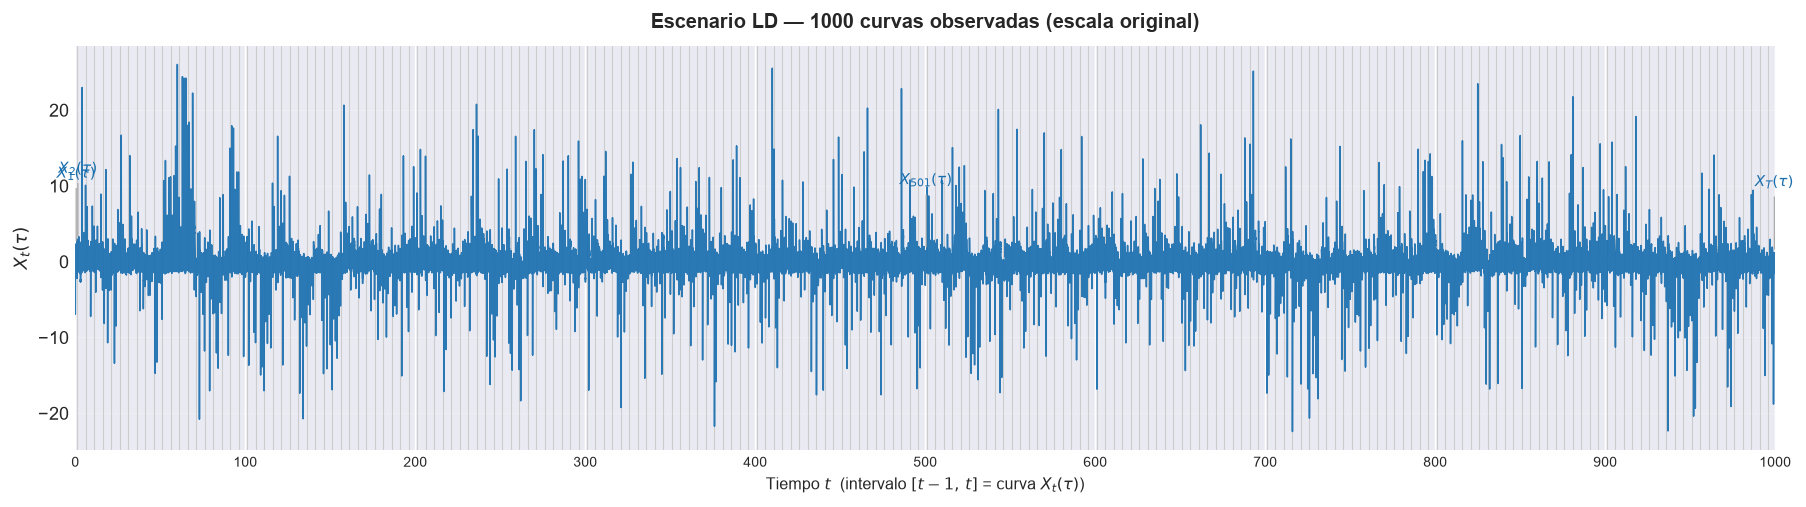

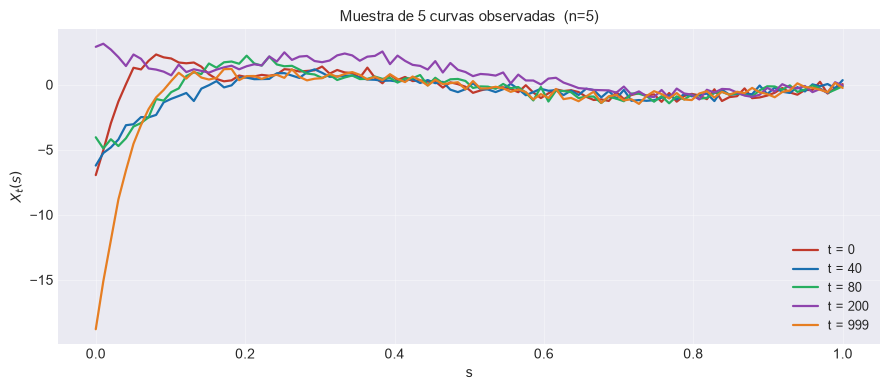

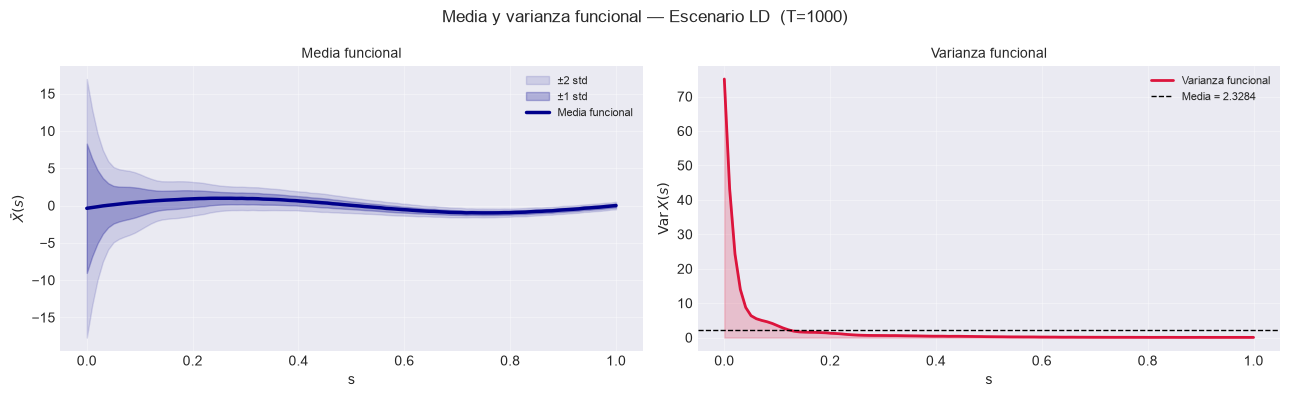

In [ ]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario LD — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario LD")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

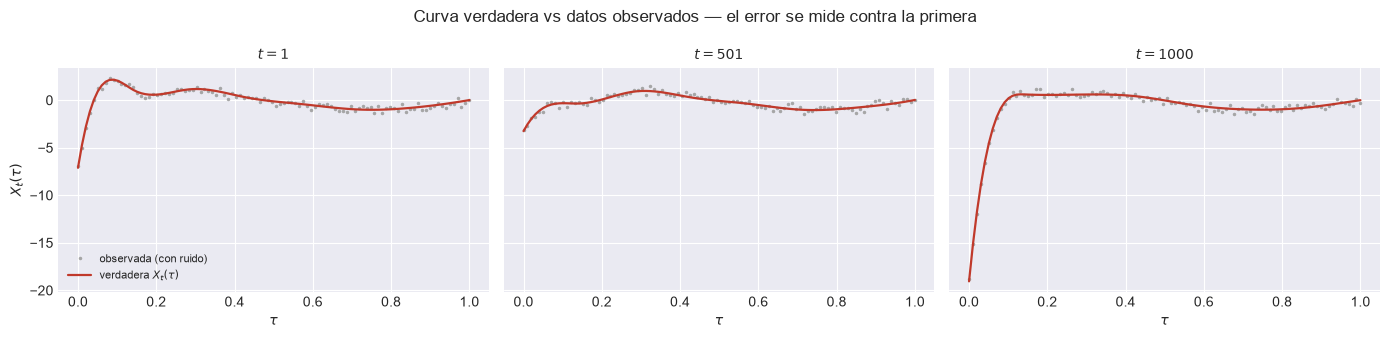

In [ ]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [ ]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 2 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 2 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 2 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [ ]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 100)
prueba        : t ∈ [701, 1000]  → (300, 100)
proporción    : 70.0% / 30.0%


## 3. Representación funcional

### 3.1 `[CONFIG]` Base fija, sin barrido GCV


Base : n_basis=10, order=4  ->  THETA (1000, 10)  (train=700, test=300)
error de representación de la curva verdadera : 6.531e-04 (relativo)
residuo sobre la observada                   : 0.2376   (ruido nominal 0.25)


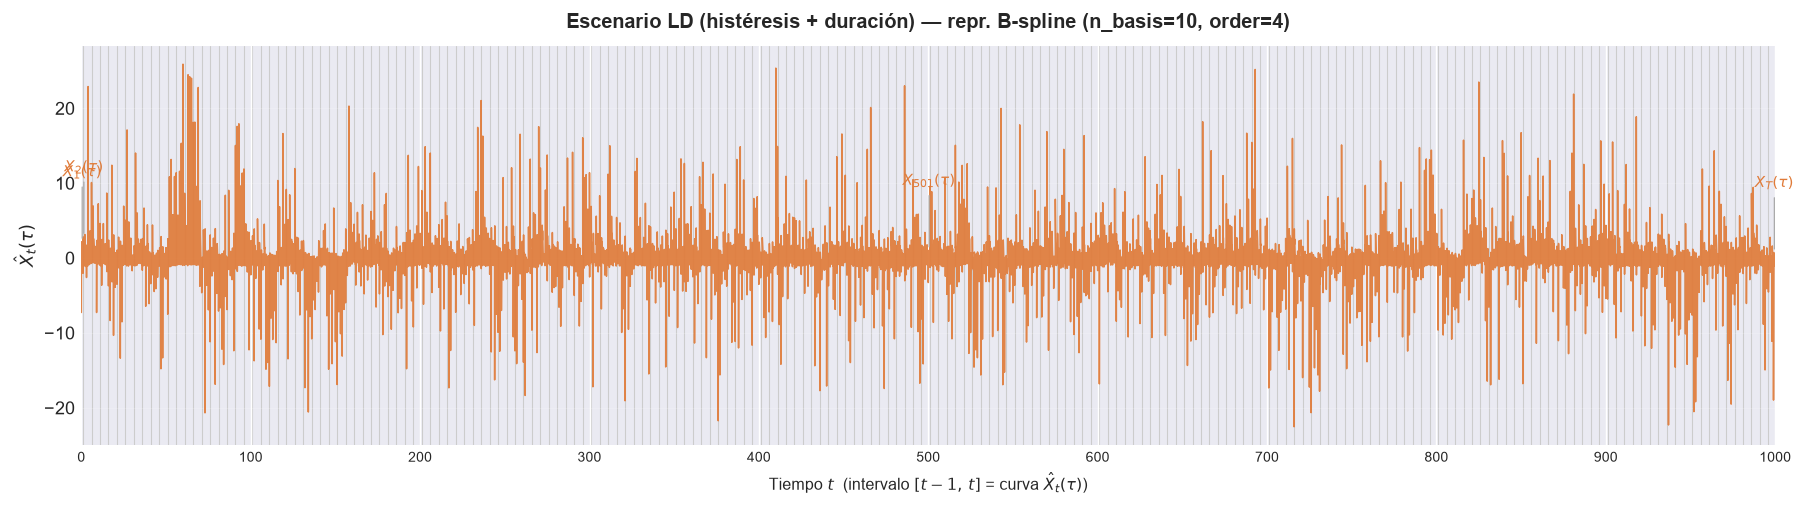

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 2 directorios)


In [ ]:
NB_ELEGIDO  = D_COEF          # = d del generador: mismo span, sin GCV
ORD_ELEGIDO = 4

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"Base : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}  ->  THETA {THETA.shape}"
      f"  (train={T0}, test={T - T0})")

# El span de la representación debe contener a la curva VERDADERA: es la
# propiedad que reemplaza al GCV y la que hace que el error de representación
# sea nulo. Si esto falla, la base y el generador dejaron de coincidir.
_rec_true = fr.reconstruct(fr.transform(X_true, grilla))
_err_true = np.abs(X_true - _rec_true).max() / X_true.std()
print(f"error de representación de la curva verdadera : {_err_true:.3e} (relativo)")
assert _err_true < 1e-2, (
    f"La base no contiene a la curva verdadera ({_err_true:.3e}): revise que "
    f"n_basis y order coincidan con `d` y `orden_bspline` del generador.")

# Sobre la OBSERVADA el residuo es el ruido de medición que el suavizado filtra,
# y debe quedar del orden de SIGMA_OBS. Muy por debajo significaría que la base
# está interpolando el ruido en vez de filtrarlo.
_rmse_obs = float(np.sqrt(((X - fr.reconstruct(THETA)) ** 2).mean()))
print(f"residuo sobre la observada                   : {_rmse_obs:.4f}"
      f"   (ruido nominal {SIGMA_OBS})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario LD (histéresis + duración) — repr. B-spline "
          f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "seleccion_base": "fija_igual_al_generador",
           "err_repr_true_rel": float(_err_true)})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")


### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [ ]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 700
  cond_W                             = 2.681e+01
  err_ortonormalidad_L2              = 1.998e-15
  err_ortonormalidad_gram            = 1.998e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.699e-16
  err_media_scores_rel               = 3.186e-15
  err_var_scores_vs_lambda           = 6.661e-16
  err_var_scores_vs_lambda_rel       = 6.157e-15
  err_correlacion_lag0               = 1.441e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok    

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,1.2779e+00,67.5368%,67.5368%,+0.376
1,2,4.1378e-01,21.8677%,89.4045%,+0.095
2,3,1.3818e-01,7.3026%,96.7071%,-0.035
3,4,4.6747e-02,2.4705%,99.1776%,+0.119
4,5,9.8000e-03,0.5179%,99.6955%,+0.046
5,6,3.1203e-03,0.1649%,99.8604%,-0.077
6,7,9.1563e-04,0.0484%,99.9088%,+0.001
7,8,6.7471e-04,0.0357%,99.9444%,-0.008
8,9,5.9184e-04,0.0313%,99.9757%,-0.004
9,10,4.5981e-04,0.0243%,100.0000%,-0.048



K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 3
  M=1: var. acum = 67.5368%  ·  sensibilidad
  M=2: var. acum = 89.4045%  ·  sensibilidad


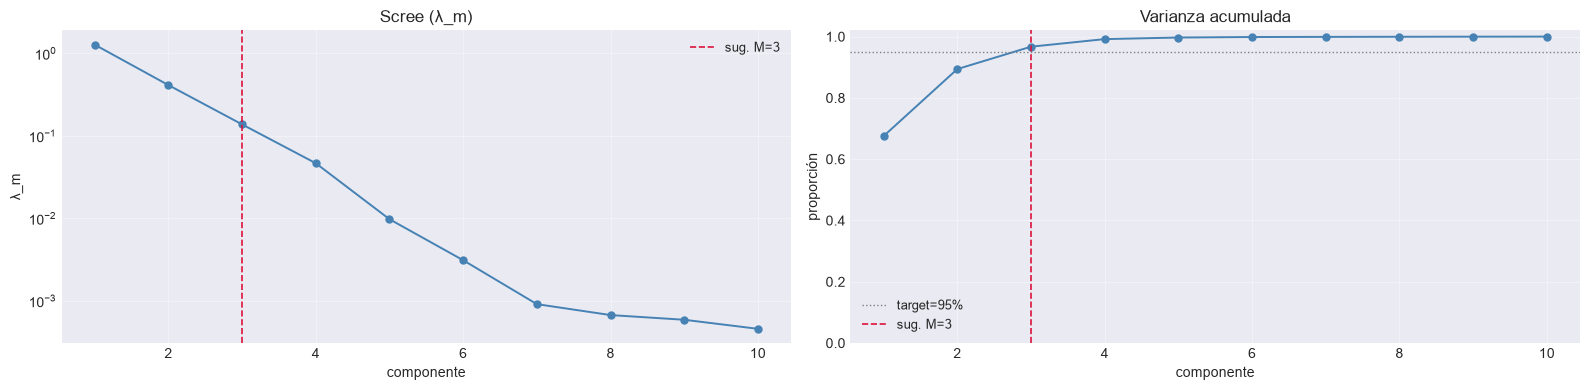

In [ ]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")


assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

| Bloque | Qué hace |
|---|---|
| §4.1 | `set_M(M)` y scores; contraste con la regla del 95 % |
| §4.2 | estandarización (**sólo train**) y artefactos FPCA |
| §4.3 | diagnóstico de rezagos sobre el bloque de entrenamiento |
| §4.4 | orden AR y construcción de los datasets |
| §4.5 | hiperparámetros y `mcmc_config` — el contrato con MATLAB |
| §4.6 | `eval_config`, líneas base y `verificar_contrato` |

In [ ]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    # M se declara en la celda [BARRIDO] de §1.1 porque forma parte del
    # EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Aquí sólo se
    # consume y se contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Estandarización ------------------------------------------------
    # Se ajusta SÓLO con train y registra n_ajuste para que esa disciplina sea
    # auditable desde el artefacto y no una promesa del notebook. La ausencia
    # de fuga en el FPCA ya es propiedad de la clase (su fit vio sólo train);
    # aquí no se reajusta nada, sólo se trunca.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    SCORES_STD       = scores_standardizer.transform(SCORES)
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}")
    print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (~0)")
    print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (~0)")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi estandarizados"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    # Los rezagos del primer origen de prueba vienen del final del bloque de
    # entrenamiento: son observaciones pasadas disponibles en cada origen, de
    # modo que su uso es el condicionamiento de la predicción a h=1, no fuga.
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "standardized_zscore_ddof0",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC: el contrato con MATLAB -----------------
    # psbp_fd_iteracion.m lee estos valores del JSON y no los tiene escritos a
    # mano, incluida seed_base. Ojo con la doble acepción de M: dentro de
    # mcmc_config es el tamaño de la grilla de localización G* del
    # stick-breaking, NO el número de componentes FPCA; N es el truncamiento
    # del número de átomos.
    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    # La escalera se indexa por k y NO se extrapola: si el barrido pidiera mas
    # componentes que peldaños definidos, falla aqui en vez de reusar el ultimo
    # en silencio, que haria que dos componentes distintas compartieran prior
    # sin que quede registrado en ningun lado.
    assert all(k in HP_ESCALERA for k in range(n_components)), (
        f"HP_ESCALERA no cubre k=0..{n_components-1}: {sorted(HP_ESCALERA)}")

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc   = HP_ESCALERA[k]
        tipos = [_clasificar(nm, k) for nm in cov_names]
        vals  = np.empty((len(cov_names), 4), dtype=float)        # (p, 4)
        vals[:, 0] = esc["apij"]      # los cuatro los fija la escalera, no el tipo
        vals[:, 1] = esc["bpij"]
        vals[:, 2] = esc["mupsij"]
        vals[:, 3] = esc["taupsij"]
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": esc["atau"], "btau": esc["btau"],
            "apij": vals[:, 0], "bpij": vals[:, 1],
            "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
        print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            marca = "  <" if _clasificar(nm, k) == "own_lag1" else ""
            print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
                  f"{a/(a+b):>7.3f}{marca}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      {t: list(v) for t, v in HP_BY_TYPE.items()},
        "escalera":     HP_ESCALERA,   # queda en el artefacto: es lo que define la 45
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "standardized_zscore_ddof0",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    # objetivo_evaluacion y modo_residuo se declaran aquí porque cambian el
    # significado de toda la evaluación y no deben quedar como una decisión
    # implícita del notebook _04. Son idénticos entre puntos del barrido, y
    # 46_04 lo exige con assert.
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "standardized_zscore_ddof0",
        "objetivo_evaluacion": "curva_verdadera",
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_true, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva VERDADERA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

N_LAGS      : 3
MCMC_CONFIG : {'nsim': 4500, 'burn': 2500, 'N': 50, 'M': 50}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (4500 - 2500) x 2 = 4000

M = 1   ·   escenario_LD_v1_1_r01_m01
M(95 %) según la regla : 3   (K disponible = 10)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 67.5368%
[train] max|media xi| = 5.08e-18   (~ 0)
[test]  max|media xi| = 0.247
[test]  var xi / lambda = [1.049]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 1)
  [train] max|media| = 2.54e-18  (~0)
  [train] max|std-1| = 1.11e-16  (~0)
  [test]  media = [0.219]
  [test]  std   = [1.023]

[functional] artefactos FPCA · cond_W = 2.681e+01


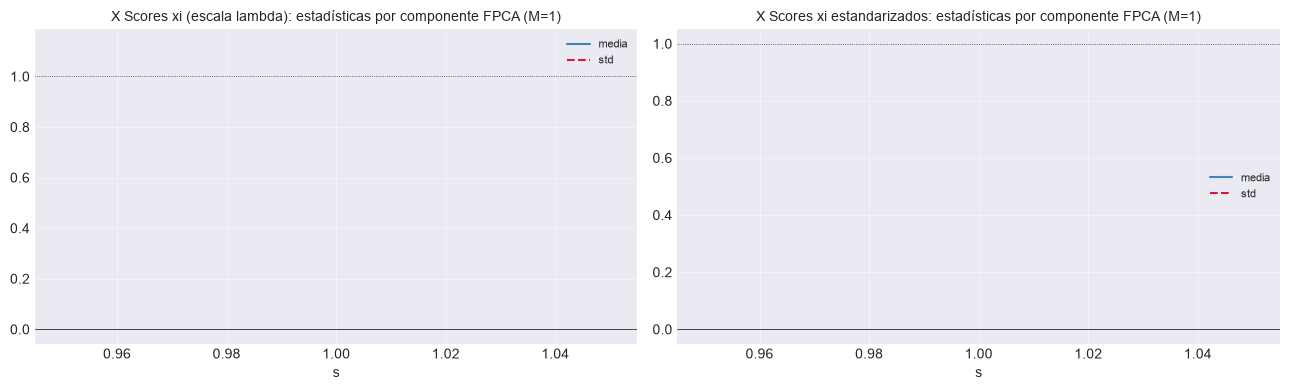

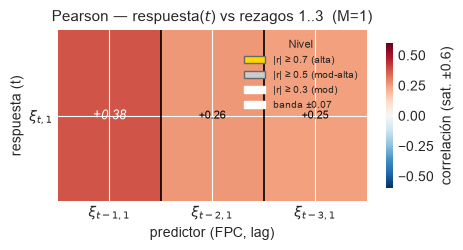

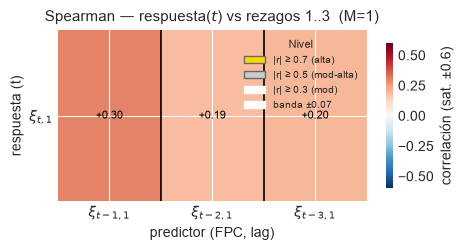

componentes : 1 -> índices [0]
N_LAGS      : 3   ·   p = 3 covariables
n_train_eff : 697   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (697, 4) · test (300, 4)

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       7.5    2.5   0.750  <
  fpc_1_lag2             cross_lag      7.5    2.5   0.750
  fpc_1_lag3             cross_lag      7.5    2.5   0.750
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_LD_v1_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,1.0466,1.0466,-0.0458,1.9863,1.4094
persistencia_lag1,300.0000,1.1301,1.1301,-0.2193,2.2223,1.4908


contrato_ok = True   (M=1, K=10, T0=700, n_components=1)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_LD_v1_1_r01_m02
M(95 %) según la regla : 3   (K disponible = 10)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 89.4045%
[train] max|media xi| = 1.78e-17   (~ 0)
[test]  max|media xi| = 0.247
[test]  var xi / lambda = [1.049 0.945]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 2)
  [train] max|media| = 4.85e-17  (~0)
  [train] max|std-1| = 4.44e-16  (~0)
  [test]  media = [ 0.219 -0.135]
  [test]  std   = [1.023 0.971]

[functional] artefactos FPCA · cond_W = 2.681e+01


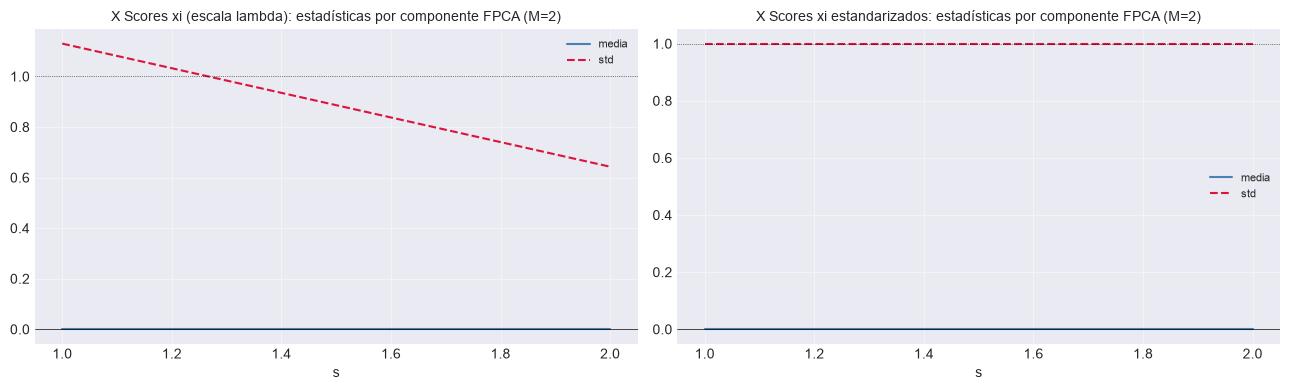

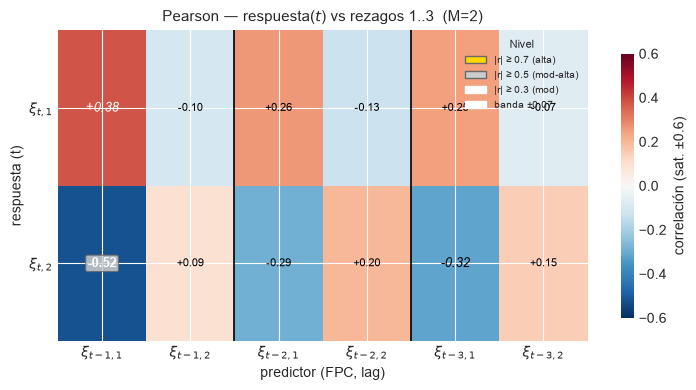

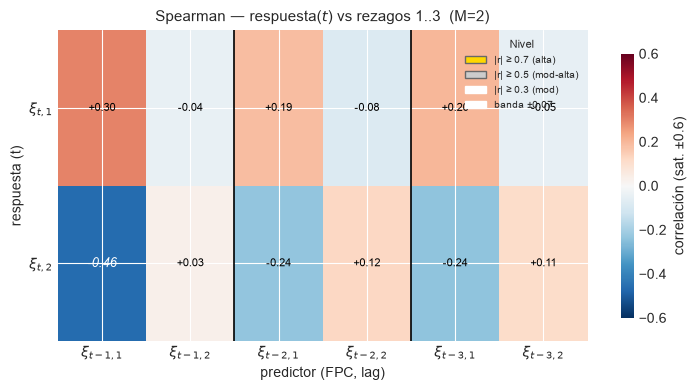

componentes : 2 -> índices [0, 1]
N_LAGS      : 3   ·   p = 6 covariables
n_train_eff : 697   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_1_lag3', 'fpc_2_lag3']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (697, 7) · test (300, 7)
  fpc_2: train (697, 7) · test (300, 7)

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       7.5    2.5   0.750  <
  fpc_2_lag1             cross_lag      7.5    2.5   0.750
  fpc_1_lag2             cross_lag      7.5    2.5   0.750
  fpc_2_lag2             cross_lag      7.5    2.5   0.750
  fpc_1_lag3             cross_lag      7.5    2.5   0.750
  fpc_2_lag3             cross_lag      7.5    2.5   0.750

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      2.0    8.0   0.200
  fpc_2_

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,1.0466,0.9806,1.0136,-0.0325,1.9863,1.4094
persistencia_lag1,300.0000,1.1301,1.3091,1.2196,-0.5179,2.5359,1.5925


contrato_ok = True   (M=2, K=10, T0=700, n_components=2)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True


In [ ]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 3
MCMC_CONFIG = {"nsim": 4500, "burn": 2500, "N": 50, "M": 50}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 1.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

HP_BY_TYPE = {
    "own_lag1":  (None, None, None, None),
    "cross_lag": (None, None, None, None),
}

# [ESCALERA] Priors por COMPONENTE FPCA, indexados por k (base-0). Son los
# MISMOS de la corrida 45, sin cambiar un valor: la 46 cambia el generador, no
# el ajuste. La 45 es el control con el que se contrasta.


HP_ESCALERA = {
    # E[tau]=3, E[pi]=0.75 (el del 44), gating EN EL MAXIMO
    0: {"atau": 1.5, "btau": 0.5, "apij": 7.5, "bpij": 2.5,
        "mupsij": 0.12, "taupsij": 10.0},
    # E[tau]=3, E[pi]=0.20, gating MUY atenuado: sd de v_h(x) = 0.016, es
    # decir 4.6 veces menos que k=0, y sujeto corto (taupsij 100 -> sd del
    # prior de psi = 0.10) para que la posterior no lo suba.
    1: {"atau": 3.0, "btau": 1.0, "apij": 2.0, "bpij": 8.0,
        "mupsij": 0.015, "taupsij": 100.0},
}

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [ ]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 46_03, 46_04 y 46_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_LD_v1_1_r01_m01,67.5368%,10,False,1,3,True
2,escenario_LD_v1_1_r01_m02,89.4045%,10,False,2,6,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2]  (el mismo de 46_03, 46_04 y 46_05)
